In [25]:
import os
import numpy as np
import utm

class OxtData:
    def __init__(self, lat, lon, alt, roll, pitch, yaw, pos_accuracy):
        self.lat = lat
        self.lon = lon
        self.alt = alt
        self.roll = roll
        self.pitch = pitch
        self.yaw = yaw
        self.pos_accuracy = pos_accuracy

def read_oxt_file(file_path):
    with open(file_path, 'r') as file:
        line = file.readline()
        data = list(map(float, line.split()))
        # Assuming the order of data is: lat, lon, alt, roll, pitch, yaw, pos_accuracy
        oxt_data = OxtData(*data[:7])
    return oxt_data

def convert_to_utm(oxt_data):
    # Convert latitude and longitude to UTM coordinates
    x, y, zone_number, zone_letter = utm.from_latlon(oxt_data.lat, oxt_data.lon)
    return x, y, zone_number, zone_letter

def calculate_distance(p1, p2):
    # Calculate Euclidean distance between two points
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def process_oxts_folder(folder_path, start_index=22, distance_threshold=2.0):
    utm_pose = []
    last_utm = None
    utm_to_info = {}

    # Sort the files by their numerical part
    files = sorted([f for f in os.listdir(folder_path) if f.endswith('.txt')], key=lambda x: int(x.split('.')[0]))

    for i, filename in enumerate(files):
        if i < start_index:
            continue
        
        file_path = os.path.join(folder_path, filename)
        oxt_data = read_oxt_file(file_path)
        x, y, zone_number, zone_letter = convert_to_utm(oxt_data)
        
        if last_utm is None or calculate_distance(last_utm, (x, y)) >= distance_threshold:
            utm_pose.append((x, y, zone_number, zone_letter))
            last_utm = (x, y)
            # Record the UTM coordinates, latitude, longitude, and filename
            utm_to_info[(x, y, zone_number, zone_letter)] = {
                'lat': oxt_data.lat,
                'lon': oxt_data.lon,
                'filename': filename
            }

    return utm_pose, utm_to_info

def calculate_relative_positions(utm_pose, num_points=15):
    trajectory_ins = {}
    
    for i, current_point in enumerate(utm_pose):
        if i + num_points > len(utm_pose):
            # If there are fewer than num_points points after the current point, skip it
            continue
        
        relative_positions = []
        for j in range(i, i + num_points):
            next_point = utm_pose[j]
            dx = next_point[0] - current_point[0]
            dy = next_point[1] - current_point[1]
            relative_positions.append((-dx, -dy))  # 注意转换坐标系
        
        # Store the relative positions in the dictionary
        trajectory_ins[current_point] = relative_positions
    
    return trajectory_ins

def calculate_past_relative_positions(utm_pose, num_points=5):
    trajectory_ins_past = {}
    
    for i, current_point in enumerate(utm_pose):
        if i < num_points:
            # If there are fewer than num_points points before the current point, skip it
            continue
        
        relative_positions = []
        for j in range(i - 1, max(i - num_points - 1, -1), -1):
            prev_point = utm_pose[j]
            dx = current_point[0] - prev_point[0]
            dy = current_point[1] - prev_point[1]
            relative_positions.append((-dx, -dy)) # 注意转换坐标系
        
        # Store the relative positions in the dictionary
        trajectory_ins_past[current_point] = relative_positions
    
    return trajectory_ins_past

# Path to the OXTS data folder
folder_path = '/home/users/xzh/trajectory-prediction/datasets/my_test10/oxts/data'

# Process all OXTS files in the folder starting from the 22nd file
utm_pose, utm_to_info = process_oxts_folder(folder_path)

# Function to get the latitude, longitude, and filename for a given UTM coordinate
def get_info_for_utm(utm_coord, utm_to_info):
    return utm_to_info.get(utm_coord, None)

# Example usage
utm_coord = utm_pose[0]  # Example UTM coordinate
info = get_info_for_utm(utm_coord, utm_to_info)
if info:
    print(f"UTM Coordinate: {utm_coord}")
    print(f"Latitude: {info['lat']}, Longitude: {info['lon']}, Filename: {info['filename']}")
else:
    print("UTM coordinate not found.")

# Calculate the relative positions for each point in the UTM coordinates
trajectory_ins = calculate_relative_positions(utm_pose)

# # Optionally, print out the trajectory_ins dictionary
# for point, rel_positions in trajectory_ins.items():
#     print(f"Point: x={point[0]}, y={point[1]}, Zone Number={point[2]}, Zone Letter={point[3]}")
#     for dx, dy in rel_positions:
#         print(f"\tRelative Position: dx={dx}, dy={dy}")

# Calculate the past relative positions for each point in the UTM coordinates
trajectory_ins_past = calculate_past_relative_positions(utm_pose)

# Optionally, print out the trajectory_ins_past dictionary
# for point, rel_positions in trajectory_ins_past.items():
#     print(f"Point: x={point[0]}, y={point[1]}")
#     for dx, dy in rel_positions:
#         print(f"\tRelative Position: dx={dx}, dy={dy}")

UTM Coordinate: (461846.6285936256, 5424529.115667883, 32, 'U')
Latitude: 48.972494784142, Longitude: 8.4786555328752, Filename: 0000000022.txt


In [26]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import LineString
import utm
import os
import pandas as pd

In [27]:
# 经纬度坐标

utm_coord = utm_pose[0]  # Example UTM coordinate
info = get_info_for_utm(utm_coord, utm_to_info)
# 定义文件路径和中心点
center_point = (info['lat'], info['lon'])  # 替换为实际的经纬度值
dist = 40 # 裁剪距离，单位米
north, south, east, west = ox.utils_geo.bbox_from_point(center_point,dist=dist)

In [28]:
G = ox.graph.graph_from_point(center_point, dist=dist, simplify=False, truncate_by_edge=True)

/home/users/xzh/anaconda3/envs/osmnx/lib/python3.8/site-packages/osmnx/graph.py:191: FutureWarning: The expected order of coordinates in `bbox` will change in the v2.0.0 release to `(left, bottom, right, top)`.
  G = graph_from_bbox(


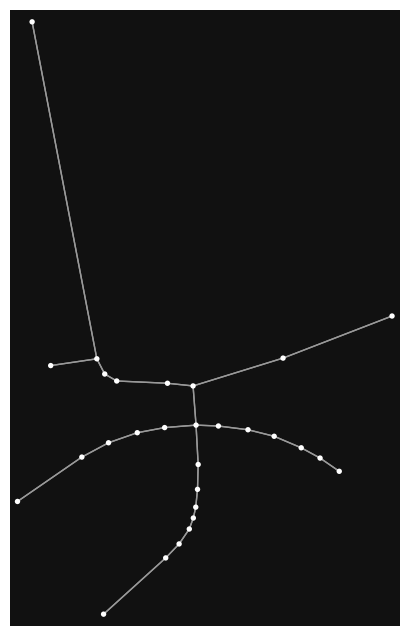

(<Figure size 800x800 with 1 Axes>, <AxesSubplot:>)

In [29]:
# 裁剪图以匹配边界框
graph_clipped = G
# 绘制图形
ox.plot_graph(graph_clipped)

In [30]:
# Directory containing the OXTS data files
directory = '/home/users/xzh/trajectory-prediction/datasets/my_test10/oxts/data/'
import re
# 使用正则表达式提取数字部分
match = re.search(r'\d+', info['filename'])
if match:
    number_str = match.group()
    number = int(number_str)
    print(number)  # 输出: 22
else:
    print("No number found in the filename.")

file_names = [f'{i:010}.txt' for i in range(number-22,number+78)]
# Construct full file paths
file_paths = [os.path.join(directory, name) for name in file_names]

# 读取 OXTS 数据文件，提取经纬度值
def read_oxts_files(file_paths):
    all_coords = []
    for file_path in file_paths:
        with open(file_path, 'r') as file:
            line = file.readline()
            data = list(map(float, line.split()))
            # 假设数据顺序为：lat, lon, alt, roll, pitch, yaw, pos_accuracy
            lat, lon = data[0], data[1]
            # print(f"lat: {lat}, lon: {lon}")
            all_coords.append((lon, lat))  # 注意这里经纬度的顺序
    return all_coords

all_coords_data = read_oxts_files(file_paths)
nodes = []
for coord in all_coords_data:
    # print(coord)
    node = ox.distance.nearest_nodes(graph_clipped, coord[0], coord[1])# 先lon,再lat
    # print(node)
    nodes.append(node)

route = nx.shortest_path(graph_clipped, nodes[0], nodes[-1], weight='length')
print(route)

22
[28231764, 26939429, 1175051016, 7524547437, 26939430, 11285058569, 1175051060, 11285058570, 26939431, 1175051218]


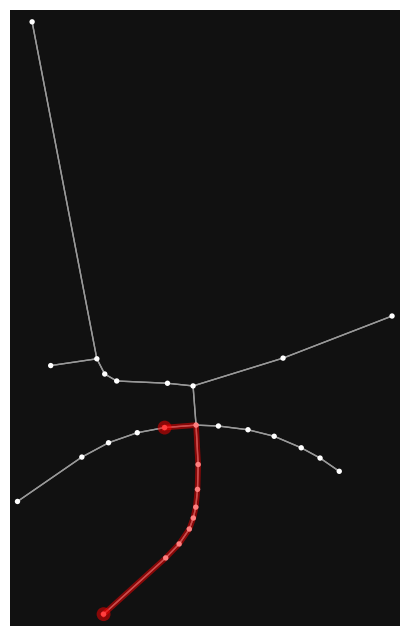

In [31]:
fig, ax = ox.plot_graph_route(graph_clipped, route) #可视化结果
# 显示图形
plt.show()

In [32]:
# 获取 nodes 和 edges 数据框
nodes, edges = ox.graph_to_gdfs(graph_clipped)
# 提取 route 中所有节点的经纬度信息
route_nodes = nodes.loc[route]
route_lat_lon = route_nodes[['y', 'x']]  # 'y' 是纬度，'x' 是经度

print(route_lat_lon)

                     y         x
osmid                           
28231764     48.972555  8.478531
26939429     48.972561  8.478661
1175051016   48.972454  8.478670
7524547437   48.972386  8.478668
26939430     48.972338  8.478660
11285058569  48.972308  8.478650
1175051060   48.972278  8.478634
11285058570  48.972237  8.478591
26939431     48.972199  8.478535
1175051218   48.972046  8.478278


In [33]:
# 将unique_a转换为utm
def gps_to_utm(lat, lon):
    """
    Convert GPS coordinates (latitude, longitude, altitude) to UTM coordinates.

    Parameters:
    - lat: float, latitude in degrees
    - lon: float, longitude in degrees
    - alt: float, altitude in meters

    Returns:
    - x: float, UTM x-coordinate
    - y: float, UTM y-coordinate
    """
    x, y, zone_number, zone_letter = utm.from_latlon(lat, lon)
    return x, y
# 将 route_lat_lon 中的经纬度转换为 UTM 坐标
route_utm = route_lat_lon.apply(lambda row: gps_to_utm(row['y'], row['x']), axis=1)
route_utm = pd.DataFrame(route_utm.tolist(), columns=['x', 'y'], index=route_lat_lon.index)
print(route_utm)
def distance(p1, p2):
    """ 计算两点之间的欧几里得距离 """
    return np.sqrt((p2[0] - p1[0]) ** 2 + (p2[1] - p1[1]) ** 2)
# route_coords_utm = []
# for coord in unique_a:
#     print(coord)
#     x, y = gps_to_utm(coord[1], coord[0])
#     print(f"UTM coordinates: {x}, {y}")
#     route_coords_utm.append((x, y))

# Convert translations to a numpy array
translations = np.array(route_utm)

# Use the first point as the origin
# translations -= translations[0]

print(translations)
# 获取第一个点和最后一个点
first_point = translations[0]
last_point = translations[-1]

# 计算第一个点和最后一个点之间的距离
dist = distance(first_point, last_point)

print(f"第一个点和最后一个点之间的距离为: {dist:.2f} 米")
# # Plot the trajectory
# plt.figure(figsize=(10, 8))
# plt.plot(-translations[:, 0], -translations[:, 1], label='Trajectory')
# plt.scatter(-translations[0, 0], -translations[0, 1], color='red', label='Start Point')
# plt.scatter(-translations[-1, 0], -translations[-1, 1], color='green', label='End Point')
# plt.title('Vehicle Trajectory')
# plt.xlabel('X coordinate (m)')
# plt.ylabel('Y coordinate (m)')
# plt.legend()
# plt.grid(True)
# plt.show()

                         x             y
osmid                                   
28231764     461837.560638  5.424536e+06
26939429     461847.116039  5.424537e+06
1175051016   461847.678166  5.424525e+06
7524547437   461847.428837  5.424517e+06
26939430     461846.857595  5.424512e+06
11285058569  461846.095863  5.424508e+06
1175051060   461844.850819  5.424505e+06
11285058570  461841.724129  5.424501e+06
26939431     461837.618769  5.424496e+06
1175051218   461818.620538  5.424479e+06
[[ 461837.56063782 5424535.82761179]
 [ 461847.1160392  5424536.50684516]
 [ 461847.67816573 5424524.57451745]
 [ 461847.42883673 5424517.03894852]
 [ 461846.85759465 5424511.65115744]
 [ 461846.09586261 5424508.36577434]
 [ 461844.85081868 5424505.03924145]
 [ 461841.72412915 5424500.53611495]
 [ 461837.61876939 5424496.32875   ]
 [ 461818.62053848 5424479.41696831]]
第一个点和最后一个点之间的距离为: 59.51 米


In [34]:
import numpy as np
from scipy.interpolate import interp1d

# 给定的点集合
points = translations
# 计算每个点之间的距离
distances = [0]
for i in range(1, len(points)):
    dist = np.linalg.norm(points[i] - points[i-1])
    distances.append(dist)
cumulative_distances = np.cumsum(distances)

# 创建插值函数
x = points[:, 0]
y = points[:, 1]

f_x = interp1d(cumulative_distances, x, kind='linear')
f_y = interp1d(cumulative_distances, y, kind='linear')

# 插值步长
step = 0.1
new_distances = np.arange(0, cumulative_distances[-1], step)

# 插值结果
new_x = f_x(new_distances)
new_y = f_y(new_distances)

# 合并插值结果为一个新的二维数组
interpolated_points = np.column_stack((new_x, new_y))

# 输出插值后的一维数组
# result = interpolated_points.flatten()
print(interpolated_points)



[[ 461837.56063782 5424535.82761179]
 [ 461837.66038613 5424535.83470227]
 [ 461837.76013444 5424535.84179275]
 ...
 [ 461818.77203895 5424479.55183049]
 [ 461818.6973458  5424479.48534039]
 [ 461818.62265265 5424479.41885029]]


In [35]:

# 已知的指定点
target_point = np.array([461847.67816573, 5424524.57451745])

# 找到与 target_point 最近的点
distances = np.linalg.norm(interpolated_points - target_point, axis=1)
nearest_index = np.argmin(distances)
current_point = interpolated_points[nearest_index]
print(current_point)

# 计算每个点之间的距离
distances_from_current = np.linalg.norm(interpolated_points - current_point, axis=1)
# print(distances_from_current)

# 创建一个轨迹数组
trajectory_hmi = [current_point]

# 找到后续每隔2米的点
current_distance = 2
count = 1
while count < 15:
    for i, distance in enumerate(distances_from_current):
        if distance > current_distance and distance <= current_distance + 2 and i > nearest_index:
            trajectory_hmi.append(interpolated_points[i])
            current_distance += 2
            count += 1
            break

# 将 trajectory_hmi 转换为 numpy 数组
trajectory_hmi = np.array(trajectory_hmi)
trajectory_hmi -= trajectory_hmi[0]
trajectory_hmi = -trajectory_hmi

# 输出结果
print(trajectory_hmi)

[ 461847.67698585 5424524.59956298]
[[-0.         -0.        ]
 [ 0.06743557  2.0988374 ]
 [ 0.13357328  4.09774355]
 [ 0.19971099  6.0966497 ]
 [ 0.30458117  8.09286533]
 [ 0.51544982 10.08171787]
 [ 0.72631848 12.0705704 ]
 [ 1.07173597 14.0367794 ]
 [ 1.52346295 15.98509733]
 [ 2.19269622 17.86780139]
 [ 2.99317148 19.80084479]
 [ 4.24791186 21.60794927]
 [ 5.50265224 23.41505374]
 [ 6.93801125 25.07308056]
 [ 8.54427908 26.71925906]]


In [36]:
# 创建一个轨迹数组
trajectory_hmi_backward = []
# 找到前面每隔2米的点
current_distance = 0
count = 0
while count < 5:
    for i, distance in enumerate(distances_from_current):
        if distance > current_distance and distance <= current_distance + 2 and i < nearest_index:
            trajectory_hmi_backward.append(interpolated_points[i] - current_point)
            current_distance += 2
            count += 1
            break

# 将 trajectory_hmi_backward 转换为 numpy 数组
trajectory_hmi_backward = -np.array(trajectory_hmi_backward)
print(trajectory_hmi_backward)

[[ 0.08940898 -1.89789516]
 [ 0.18352369 -3.89567954]
 [ 0.2776384  -5.89346392]
 [ 0.37175312 -7.89124829]
 [ 0.46586783 -9.88903267]]
